In [1]:
#pip install xlrd

In [2]:
#pip install openpyxl

In [3]:
#!pip install phik -q 

In [4]:
#!pip install lightgbm 

In [5]:
#pip install optuna

In [6]:
#pip install optuna-integration[sklearn]

### Импорты и объявление переменных

In [7]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from optuna import distributions
from optuna.integration import OptunaSearchCV
from sklearn.metrics import accuracy_score

In [8]:
RANDOM_STATE = 42

In [9]:
offers_num = 12

In [10]:
days_limit = 6 #срок выше которого предложения не рассматриваются

In [11]:
our_logo = "PRLQ"

In [12]:
places = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] #места, нужны чтобы привести таблицу из "горизонтального" вида в обычный

In [13]:
#Пояснения по местам
#place - место для соединения двух таблиц, содержит предложения с длинным сроком в том числе
#place_final - порядковое место, без предложений с длинным сроком
#место - исходное место нашего предложения, предложения с длинным сроком не учитываются
#Ни одно из них целевым не является!!

### Переменнные надо ПЕРЕНАЗВАТЬ в идеале более понятно

In [14]:
logo_rename_qty = 40 #если кол-во лого меньше этого значения, меняем его на OTHER
#ВАЖНО, это очень существенно зависит от количества исходных файлов
#возможно, это лучше рассчитывать

In [15]:
pricing = pd.DataFrame()

In [16]:
#ф-ция для вывода осн.инф-ции по датасетам
def dataset_describe(dataset, head=5):
    dataset.info()
    display(dataset.head(head))

In [17]:
#ф-ция для вывода первых и последних строк
def five(dataset):
    display(dataset.shape)
    display(pd.concat([dataset.head(3), dataset.tail(2)]))

### Перебор всех имеющихся файлов в папке и создание датафрейма

In [18]:
file_num = 1
for file in glob("C:/Users/a-2/jupyter project/pricing/*.xlsm"):
    print(file)
    temp_file = pd.read_excel(file,engine='openpyxl')
    temp_file['file'] = file_num
    file_num += 1
    pricing = pricing.append(temp_file)

C:/Users/a-2/jupyter project/pricing\шаблон проценки 09.04.25.xlsm


C:\Users\a-2\anaconda3\envs\practicum\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


C:/Users/a-2/jupyter project/pricing\шаблон проценки 24.01.25.xlsm
C:/Users/a-2/jupyter project/pricing\шаблон проценки 24.02.25.xlsm


In [19]:
#pricing.head(3)

In [20]:
#pricing.describe()

### Назначение имен столбцам с предложениями

In [21]:
offer_first_col = 45
offer_last_col = 104

In [22]:
for i in range(offer_first_col, offer_last_col+1):
    offer_num = (i - offer_first_col) // 5 + 1
    position = i % 5 + 1
    if position == 1:
        pricing.rename(columns={pricing.columns[i]: 'logo_' + str(offer_num)}, inplace=True)
    elif position == 2:
            pricing.rename(columns={pricing.columns[i]: 'qty_' + str(offer_num)}, inplace=True)
    elif position == 3:
            pricing.rename(columns={pricing.columns[i]: 'days_' + str(offer_num)}, inplace=True)
    elif position == 4:
            pricing.rename(columns={pricing.columns[i]: 'rub_' + str(offer_num)}, inplace=True)
    elif position == 5:
            pricing.rename(columns={pricing.columns[i]: 'usd_' + str(offer_num)}, inplace=True)
          
    #print(i, offer_num, position, pricing.columns[i])
    

### Удаление неиспользуемых столбцов

In [23]:
#Числа только здесь и это самые очевидные столбцы для удаления

In [24]:
#pricing.columns[105:131]

In [25]:
pricing.drop(columns=pricing.columns[105:131], inplace=True)

In [26]:
pricing.drop(columns=['Unnamed: 0','Unnamed: 1', '-.64'], inplace=True)

In [27]:
pricing.drop(columns=['Группа','Группа в день'], inplace=True)

In [28]:
#pricing.drop(columns=['рек. цена', 'Добавить','маржа', 'изменение цены'], inplace=True)

In [29]:
pricing.drop(columns=['Добавить','маржа', 'изменение цены'], inplace=True)

Для более точного варианта возможно нужно будет оставить эти столбцы.

In [30]:
pricing.drop(columns=['Разница с эмиратами','Разница предложения с ценой'], inplace=True)

In [32]:
pricing.drop(columns=[#'№ предложения',
       'Лого предложения', 'Кол-во предложения', 'Дней предложения',
       'Цена предложения', 'Маржа по предложению', 'До след. предложения',
       'Лого предложения.1', 'Кол-во предложения.1', '№ предложения.1',
       'Дней предложения.1', 'Цена предложения.1', 'Маржа по предложению.1'], inplace=True)

### Разбиение таблицы на две части, левую и правую, для дальнейшего сложного соединения.

Здесь из исходной таблицы, с учётом уже удаленного, нужно выбрать три части.

Первая часть, с начала (с производителя) до первого лого (logo_1), не включая его.

In [33]:
second_part_first_column = pricing.columns.get_loc('logo_1')

In [34]:
#pricing.columns[:19]

In [35]:
pricing.columns[:second_part_first_column]

Index(['Производитель', 'Номер', 'Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 'рек. цена', 'Место',
       '№ предложения'],
      dtype='object')

Вторая часть, все предложения.

In [36]:
second_part_last_column = pricing.columns.get_loc('usd_' + str(offers_num))

In [37]:
#pricing.columns[19:79]

In [38]:
#pricing.columns[second_part_first_column:second_part_last_column+1]

Третья часть, оставшиеся, имеющие для задачи смысл столбца после всех предложений. 

In [39]:
third_part_last_column = pricing.columns.get_loc('file')

In [40]:
#pricing.columns[79:83]

In [41]:
pricing.columns[second_part_last_column+1:third_part_last_column+1]

Index(['Наим.', 'кузов', 'Чей товар новый', 'file'], dtype='object')

#### Левая часть

In [42]:
#pricing_left = pricing[pricing.columns[:19]]

In [43]:
pricing_left = pricing[pricing.columns[:second_part_first_column]]

In [44]:
pricing_left = pd.concat([pricing_left,pricing[pricing.columns[second_part_last_column+1:third_part_last_column+1]]], axis=1)

In [45]:
pricing_left['key'] = pricing_left['Производитель'] + '_' + pricing_left['Номер'] + '_file' + pricing_left['file'].map(str)

In [46]:
#five(pricing_left)

In [47]:
pricing_left.columns

Index(['Производитель', 'Номер', 'Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 'рек. цена', 'Место',
       '№ предложения', 'Наим.', 'кузов', 'Чей товар новый', 'file', 'key'],
      dtype='object')

#### Места и их добавление

In [48]:
places = pd.DataFrame(places)

In [49]:
places.columns = ['place']

In [50]:
places.head(3)

,place
0,1
1,2
2,3


Добавляем места.

In [51]:
pricing_left = pricing_left.join(places, how='cross')

Создаем финальный ключ для соединения таблиц.

In [52]:
pricing_left['key_final'] = pricing_left['key'].map(str) + ' ' + pricing_left['place'].map(str)

In [53]:
#pricing_left.head(3)

#### Правая часть

In [54]:
pricing_right = pricing[['Производитель', 'Номер']].copy()

In [55]:
pricing_right = pd.concat(
    [pricing_right,
     pricing[pricing.columns[second_part_first_column:second_part_last_column+1]],
     pricing['file']
    ], axis=1)

In [56]:
pricing_right['key'] = pricing_right['Производитель'] + '_' + pricing_right['Номер'] + '_file' + pricing_right['file'].map(str)

#### Соединение левой и правой частей

In [58]:
pricing_final = pd.DataFrame()

In [59]:
temporary = pd.DataFrame()
for i in range(0, offers_num):
    #print(i)
    j = i * 5 + 2
    temp = pricing_right.loc[:,pricing_right.columns[j:j+5]]
    temp['place'] = i+1 
    temp['key_final'] = pricing_right['key'].map(str) + ' ' + temp['place'].map(str)
    temp.columns = ['logo', 'qty', 'days', 'rub', 'usd', 'place', 'key_final']
    #print(type(pricing_left))
    #print(type(temp))
    ###pricing_left = pricing_left.merge(temp, on=['key_final'], how='left')
    temporary = pricing_left.merge(temp[['logo', 'qty', 'days', 'rub', 'usd', 'key_final']], on=['key_final'], how='inner')
    pricing_final = pricing_final.append(temporary)
    print(len(pricing_final))
    #print(temp.head(3))
    #print('')

7624
15248
22872
30496
38120
45744
53368
60992
68616
76240
83864
91488


In [60]:
#five(pricing_final)

In [61]:
pricing_final.columns

Index(['Производитель', 'Номер', 'Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 'рек. цена', 'Место',
       '№ предложения', 'Наим.', 'кузов', 'Чей товар новый', 'file', 'key',
       'place', 'key_final', 'logo', 'qty', 'days', 'rub', 'usd'],
      dtype='object')

In [62]:
#dataset_describe(pricing_final)

In [63]:
pricing_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91488 entries, 0 to 7623
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             91488 non-null  object 
 1   Номер                     91488 non-null  object 
 2   Цена                      91488 non-null  float64
 3   С-ть                      91488 non-null  float64
 4   Маржа                     91224 non-null  float64
 5   Остаток                   91488 non-null  int64  
 6   Дней на складе            91488 non-null  int64  
 7   Не было продаж            91488 non-null  object 
 8   Продажи за период         91488 non-null  int64  
 9   Продажи к остаткам        91476 non-null  float64
 10  Скорость продаж           91488 non-null  float64
 11  Средн. скорость           91488 non-null  int64  
 12  С момента посл. отпр.     91488 non-null  int64  
 13  Дней назад менялась цена  91488 non-null  int64  
 14  % измен

### Предобработка данных

#### Явные задвоения

In [64]:
pricing_final.duplicated().sum()

0

Явных задвоений нет.

#### Пропуски

В явном виде покажем пропуски.

In [65]:
pricing_final.isna().sum()

Производитель                   0
Номер                           0
Цена                            0
С-ть                            0
Маржа                         264
Остаток                         0
Дней на складе                  0
Не было продаж                  0
Продажи за период               0
Продажи к остаткам             12
Скорость продаж                 0
Средн. скорость                 0
С момента посл. отпр.           0
Дней назад менялась цена        0
% изменения                     0
Мин. цена                       0
Макс. цена                      0
Общ.  с-ть                      0
рек. цена                   66120
Место                         336
№ предложения                   0
Наим.                           0
кузов                       18204
Чей товар новый                 0
file                            0
key                             0
place                           0
key_final                       0
logo                        20720
qty           

Строки с незаполненной маржей можно удалить.

In [66]:
pricing_final = pricing_final.dropna(subset=['Маржа']) 

Аналогично по продажам к остаткам.

In [67]:
pricing_final = pricing_final.dropna(subset=['Продажи к остаткам']) 

Аналогично по признаку "место".

In [68]:
pricing_final = pricing_final.dropna(subset=['Место']) 

Пустых столбцов loqo, qty и т.д. ожидаемо много.  
Все такие строки удаляю сейчас, а потом м.б. нужно будет переделать соединение, чтобы не присоединять ненужное.

#### Кузов

In [69]:
pricing_final = pricing_final.dropna(subset=['logo']) 

Пропуски в поле "кузов" заполним значением "не_определено".

In [70]:
pricing_final['кузов'] = pricing_final['кузов'].fillna('не_определено') 

In [71]:
pricing_final['кузов'].value_counts()

Не кузов          57479
не_определено      8120
Полукузов          2280
Объёмный кузов     1570
Бамперы             704
Жидкость            139
Кузов                52
0                    36
Name: кузов, dtype: int64

Также заменим на "не_определено" значения 0 и "Кузов".

In [72]:
pricing_final.loc[pricing_final['кузов']==0,'кузов'] = "не_определено"

In [73]:
pricing_final.loc[pricing_final['кузов']=="Кузов",'кузов'] = "не_определено"

#### Рек. цена

Признак рек. цена, по крайней мере на данный момент, нужен только с точки зрения менялась цена или нет.  
Но пропуски заменим нулями. 

In [74]:
pricing_final['рек. цена'] = pricing_final['рек. цена'].fillna(0)

In [75]:
pricing_final.isna().sum()

Производитель               0
Номер                       0
Цена                        0
С-ть                        0
Маржа                       0
Остаток                     0
Дней на складе              0
Не было продаж              0
Продажи за период           0
Продажи к остаткам          0
Скорость продаж             0
Средн. скорость             0
С момента посл. отпр.       0
Дней назад менялась цена    0
% изменения                 0
Мин. цена                   0
Макс. цена                  0
Общ.  с-ть                  0
рек. цена                   0
Место                       0
№ предложения               0
Наим.                       0
кузов                       0
Чей товар новый             0
file                        0
key                         0
place                       0
key_final                   0
logo                        0
qty                         0
days                        0
rub                         0
usd                         0
dtype: int

#### Замена типов данных

Рассмотрим столбец 'Не было продаж', где очевидно не подходящий тип данных.

In [76]:
pricing_final['Не было продаж'][pricing_final['Не было продаж']!='Не было продаж'].astype('int64').max()

2729

Заменим значение 'Не было продаж' на максимальное плюс 1000 дней.

In [77]:
max_days_no_sells = pricing_final['Не было продаж'][pricing_final['Не было продаж']!='Не было продаж'].astype('int64').max()

In [78]:
pricing_final.loc[pricing_final['Не было продаж']=='Не было продаж','Не было продаж'] = max_days_no_sells + 1000

In [79]:
pricing_final['Не было продаж'] = pricing_final['Не было продаж'].astype('int64')

В признаке "Место" также поменяем тип данных.

In [80]:
pricing_final['Место'] = pricing_final['Место'].astype('int64')

То же самое для признаков "qty" и "days".

In [81]:
pricing_final['qty'] = pricing_final['qty'].astype('int64')

In [82]:
pricing_final['days'] = pricing_final['days'].astype('int64')

#### Чей товар новый

In [83]:
#pricing_final['Чей товар новый'].value_counts()

#### Удаление предложений с длинным сроком

Далее оставим только позиции, подходящие по сроку без длинных предложений.  
Возможно для более сложного варианта этот момент нужно будет поменять.

In [95]:
pricing_final = pricing_final[pricing_final['days']<=days_limit]

#### Удаление предложений с отрицательными долл. ценами

In [96]:
keys_to_delete = pricing_final[pricing_final['usd']<0]['key'].unique()

In [97]:
pricing_final = pricing_final[~pricing_final['key'].isin(keys_to_delete)]

#### Коректировка признака "№ предложения"

Если рек. цена не проставлена, а "№ предложения" не совпадает с признаком "место",  
т.е. позиция была просмотрена, но цену решил не менять, то
"№ предложения" меняю на "место".

In [98]:
pricing_final.loc[(pricing_final['№ предложения'] != pricing_final['Место']) & (pricing_final['рек. цена']==0),'№ предложения'] = \
    pricing_final.loc[(pricing_final['№ предложения'] != pricing_final['Место']) & (pricing_final['рек. цена']==0),'Место']  

In [99]:
#dataset_describe(pricing_final)

In [100]:
pricing_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 44483 entries, 0 to 7623
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             44483 non-null  object 
 1   Номер                     44483 non-null  object 
 2   Цена                      44483 non-null  float64
 3   С-ть                      44483 non-null  float64
 4   Маржа                     44483 non-null  float64
 5   Остаток                   44483 non-null  int64  
 6   Дней на складе            44483 non-null  int64  
 7   Не было продаж            44483 non-null  int64  
 8   Продажи за период         44483 non-null  int64  
 9   Продажи к остаткам        44483 non-null  float64
 10  Скорость продаж           44483 non-null  float64
 11  Средн. скорость           44483 non-null  int64  
 12  С момента посл. отпр.     44483 non-null  int64  
 13  Дней назад менялась цена  44483 non-null  int64  
 14  % измен

### Исследовательский анализ данных

Столбцы file, key и key_final смысла исследовать нет. Они не удалены, т.к. возможно понадобятся для вывода результата.  
Аналогично признак "Номер". 

#### Дней на складе

count    44483.000000
mean       123.254030
std        152.624554
min          0.000000
25%         38.000000
50%         61.000000
75%        122.000000
max       2455.000000
Name: Дней на складе, dtype: float64


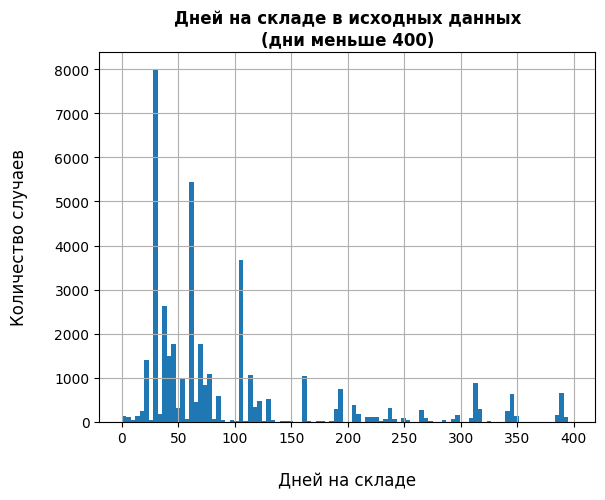

In [101]:
print(pricing_final['Дней на складе'].describe())
pricing_final[pricing_final['Дней на складе']<400]['Дней на складе'].hist(bins=100)
plt.title("Дней на складе в исходных данных\n(дни меньше 400)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней на складе", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Не было продаж

count    44483.000000
mean       519.192096
std       1179.849982
min          0.000000
25%          4.000000
50%         14.000000
75%        133.000000
max       3729.000000
Name: Не было продаж, dtype: float64


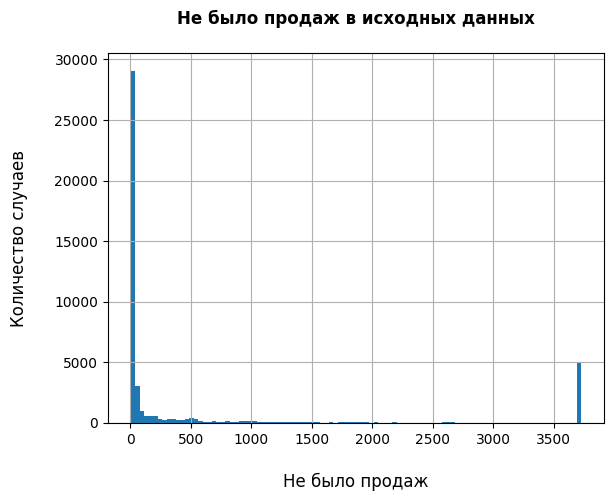

In [102]:
print(pricing_final['Не было продаж'].describe())
pricing_final['Не было продаж'].hist(bins=100)
plt.title("Не было продаж в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nНе было продаж", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Дней назад менялась цена

count    44483.000000
mean         7.845334
std          9.985028
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max        139.000000
Name: Дней назад менялась цена, dtype: float64


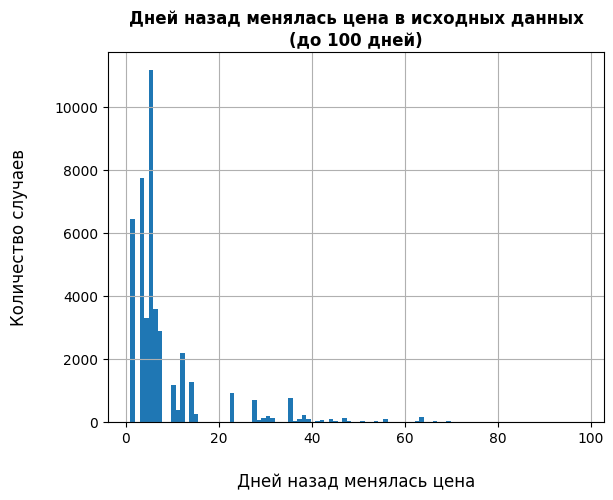

In [103]:
print(pricing_final['Дней назад менялась цена'].describe())
pricing_final[(pricing_final['Дней назад менялась цена']<=100)]['Дней назад менялась цена'].hist(bins=100)
plt.title("Дней назад менялась цена в исходных данных\n(до 100 дней)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней назад менялась цена", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Наим.

In [104]:
print(pricing_final['Наим.'].describe())

count       44483
unique       2182
top       САЛЬНИК
freq          566
Name: Наим., dtype: object


#### Place

count    44483.000000
mean         5.642448
std          3.448205
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max         12.000000
Name: place, dtype: float64


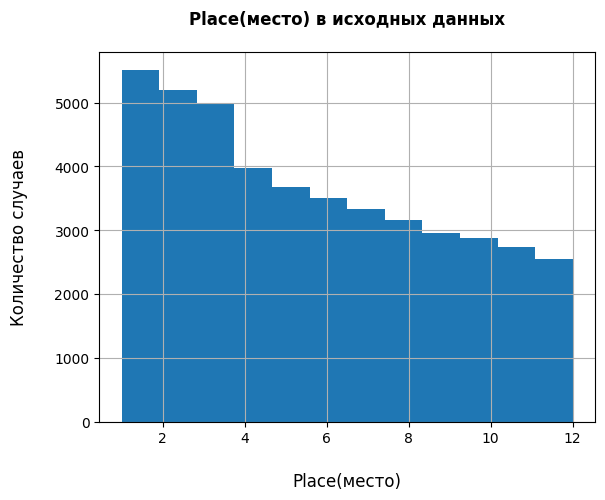

In [105]:
print(pricing_final['place'].describe())
pricing_final['place'].hist(bins=12)
plt.title("Place(место) в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace(место)", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Сделано в большей степени для проверки себя и для дальнейшего сравнения.

#### Place_final

Добавим признак Place_final. В отличие от place, который был нужен для преобразования исходной таблицы в плоский вид и показывал место с учетом предложений с длинным сроком 

In [106]:
len(pricing_final.groupby('key').cumcount())

44483

In [107]:
pricing_final['place_final'] = pricing_final.groupby('key').cumcount()

In [108]:
pricing_final['place_final'] = pricing_final['place_final'] + 1

count    44483.000000
mean         4.335364
std          2.791839
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         12.000000
Name: place_final, dtype: float64


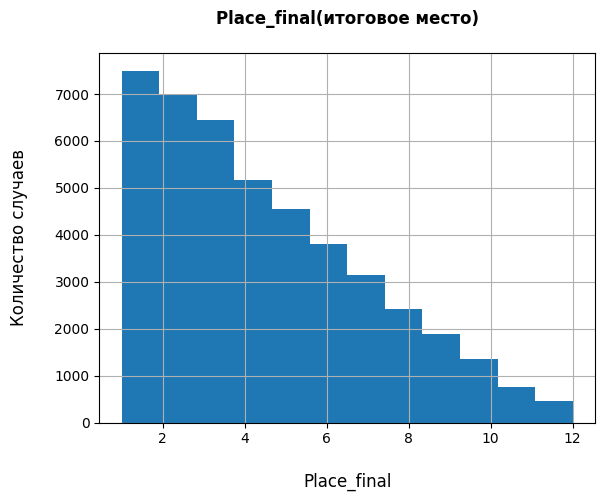

In [109]:
print(pricing_final['place_final'].describe())
pricing_final['place_final'].hist(bins=12)
plt.title("Place_final(итоговое место)\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace_final", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Logo

In [110]:
logo_qty = pricing_final['logo'].value_counts()
#logo_qty.head(10)

In [111]:
len(logo_qty)

341

Несколько сотен разных значений.

In [112]:
logo_rename_qty = file_num * 10

Посмотрим количество значений, меньше чем logo_rename_qty.

In [113]:
len(logo_qty[logo_qty<logo_rename_qty])

238

И сколько разных лого остается.

In [114]:
len(logo_qty[logo_qty>=logo_rename_qty])

103

In [115]:
logo_qty = logo_qty.reset_index()

In [116]:
logo_qty.columns = ['logo','logo_qty']

In [117]:
pricing_final = pricing_final.merge(logo_qty, on=['logo'], how='left')

Заменим лого, где кол-во лого меньше, чем logo_rename_qty, на OTHER.

In [118]:
pricing_final.loc[pricing_final['logo_qty']<logo_rename_qty,'logo'] = 'OTHER'

Возможно признак logo_qty будет уместно использовать для модели. Поэтому не удаляю его пока.


#### Qty

count    44483.000000
mean        11.755592
std         47.695373
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max       3604.000000
Name: qty, dtype: float64


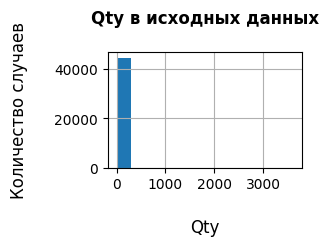

In [119]:
print(pricing_final['qty'].describe())
pricing_final['qty'].hist(bins=12, figsize=(2.5, 1.5))
plt.title("Qty в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nQty", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Посмотрим на самые большие значения

In [120]:
pricing_final['qty'].sort_values(ascending=False).head(10)

24855    3604
15349    3409
9535     2000
21766    2000
40158    2000
13106    2000
22137    1301
19616    1280
10644    1280
9220     1280
Name: qty, dtype: int64

Значение больше 200 уменьшим до 200.

In [121]:
pricing_final.loc[pricing_final['qty']>200,'qty'] = 200

count    44483.000000
mean        10.455140
std         24.082325
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max        200.000000
Name: qty, dtype: float64


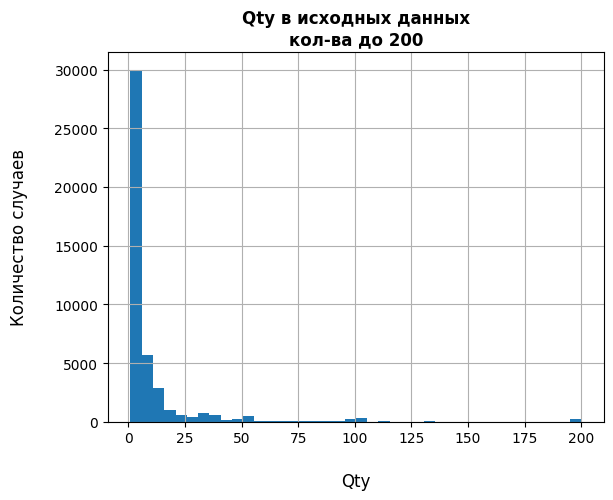

In [122]:
print(pricing_final['qty'].describe())
pricing_final[pricing_final['qty']<201]['qty'].hist(bins=40)
plt.title("Qty в исходных данных\nкол-ва до 200", fontsize=12, fontweight="bold")
plt.xlabel("\nQty", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### logo_qty

count    44483.000000
mean      2037.332666
std       2545.821732
min          1.000000
25%        343.000000
50%       1179.000000
75%       2141.000000
max       7496.000000
Name: logo_qty, dtype: float64


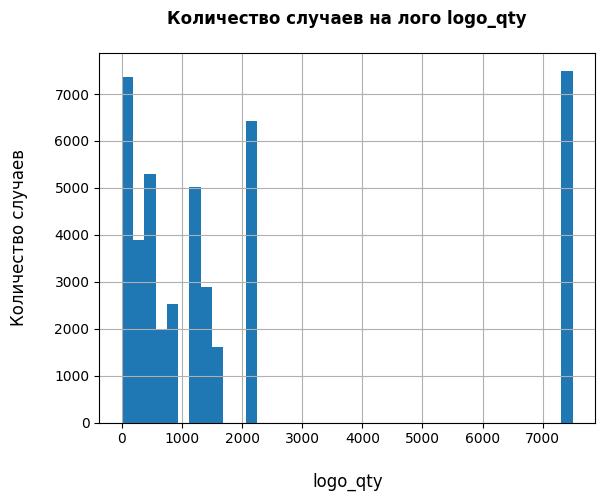

In [123]:
print(pricing_final['logo_qty'].describe())
pricing_final['logo_qty'].hist(bins=40)
plt.title("Количество случаев на лого logo_qty\n", fontsize=12, fontweight="bold")
plt.xlabel("\nlogo_qty", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Days

count    44483.000000
mean         2.876874
std          1.496850
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: days, dtype: float64


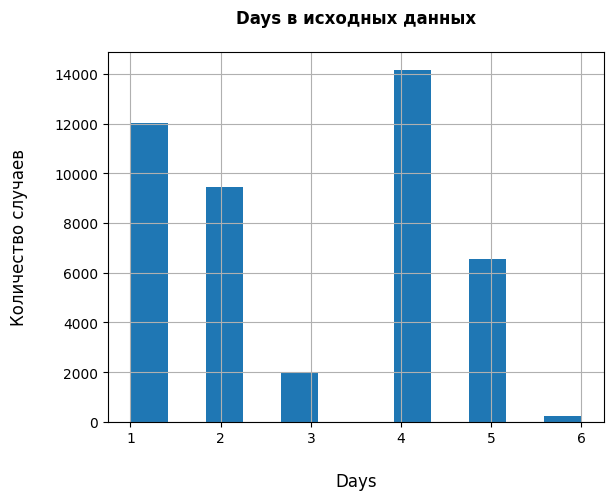

In [124]:
print(pricing_final['days'].describe())
pricing_final['days'].hist(bins=12)
plt.title("Days в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nDays", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

In [125]:
#pd.set_option('display.float_format', lambda x: '%.2f' % x)

count    4.448300e+04
mean     7.552917e+03
std      1.845819e+04
min      6.400000e+01
25%      7.920000e+02
50%      2.446560e+03
75%      7.113000e+03
max      1.513670e+06
Name: rub, dtype: float64


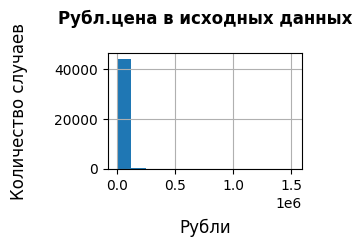

In [126]:
print(pricing_final['rub'].describe())
pricing_final['rub'].hist(bins=12, figsize=(2.5, 1.5))
plt.title("Рубл.цена в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nРубли", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

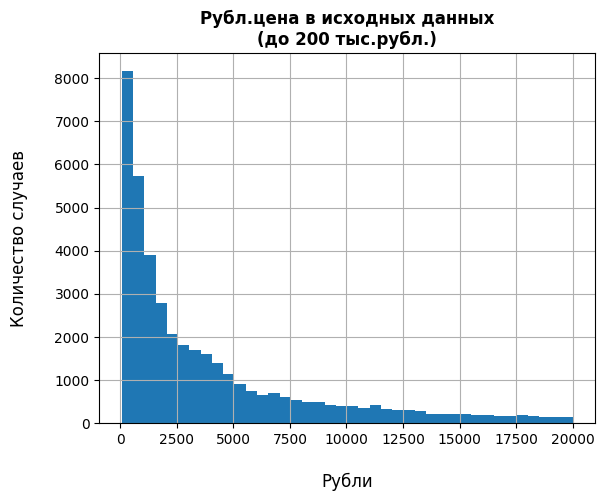

In [127]:
#print(pricing_final['rub'].describe())
pricing_final[pricing_final['rub']<20000]['rub'].hist(bins=40)
plt.title("Рубл.цена в исходных данных\n(до 200 тыс.рубл.)", fontsize=12, fontweight="bold")
plt.xlabel("\nРубли", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    44483.000000
mean        57.013186
std        140.955439
min          0.330793
25%          5.824580
50%         18.323450
75%         53.623143
max      11585.166396
Name: usd, dtype: float64


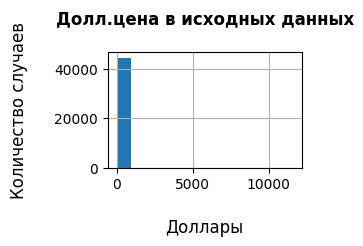

In [128]:
print(pricing_final['usd'].describe())
pricing_final['usd'].hist(bins=12, figsize=(2.5, 1.5))
plt.title("Долл.цена в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nДоллары", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

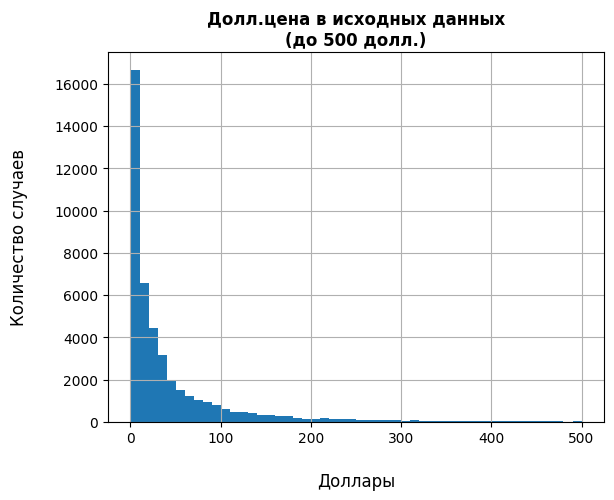

In [129]:
#print(pricing_final['usd'].describe())
pricing_final[pricing_final['usd']<500]['usd'].hist(bins=50)
plt.title("Долл.цена в исходных данных\n(до 500 долл.)", fontsize=12, fontweight="bold")
plt.xlabel("\nДоллары", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Место (нашего предложения)

count    44483.000000
mean         2.079536
std          1.321814
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: Место, dtype: float64


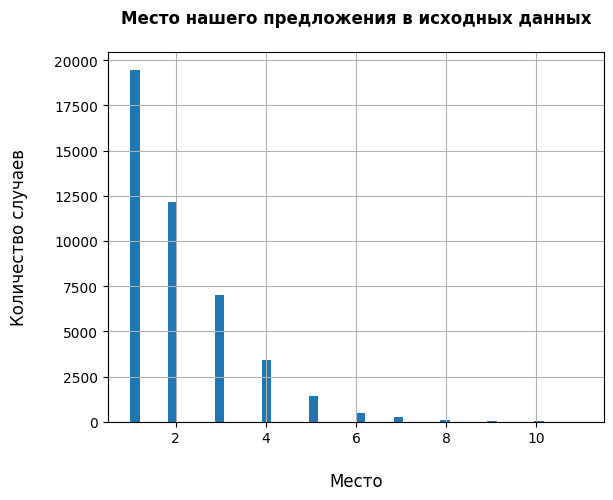

In [130]:
print(pricing_final['Место'].describe())
pricing_final['Место'].hist(bins=offers_num*4)
plt.title("Место нашего предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМесто", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### № предложения

count    44483.000000
mean         1.584448
std          1.076828
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: № предложения, dtype: float64


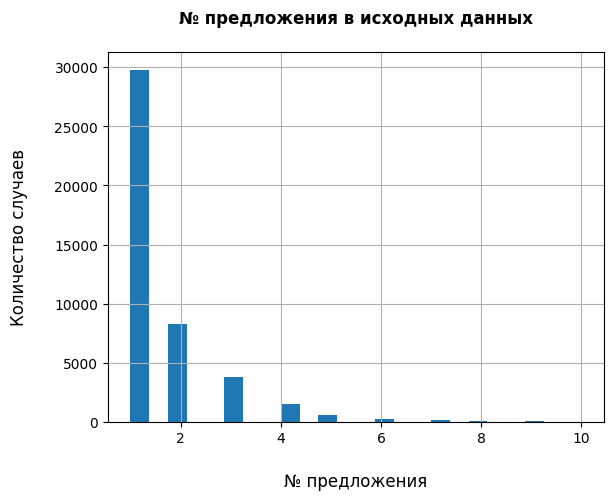

In [131]:
print(pricing_final['№ предложения'].describe())
pricing_final['№ предложения'].hist(bins=offers_num*2)
plt.title("№ предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\n№ предложения", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Количество перед предложением

In [132]:
pricing_final['Кол-во перед предл.'] = pricing_final.groupby('key')['qty'].cumsum() - pricing_final['qty']

count    44483.000000
mean        44.921543
std         96.407907
min          0.000000
25%          2.000000
50%         11.000000
75%         38.000000
max       1295.000000
Name: Кол-во перед предл., dtype: float64


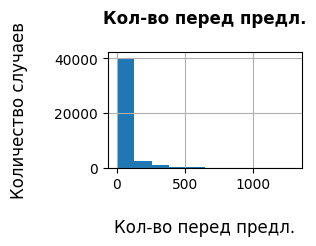

In [133]:
print(pricing_final['Кол-во перед предл.'].describe())
pricing_final['Кол-во перед предл.'].hist(bins=10, figsize=(2.5, 1.5))
plt.title("Кол-во перед предл.\n", fontsize=12, fontweight="bold")
plt.xlabel("\nКол-во перед предл.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

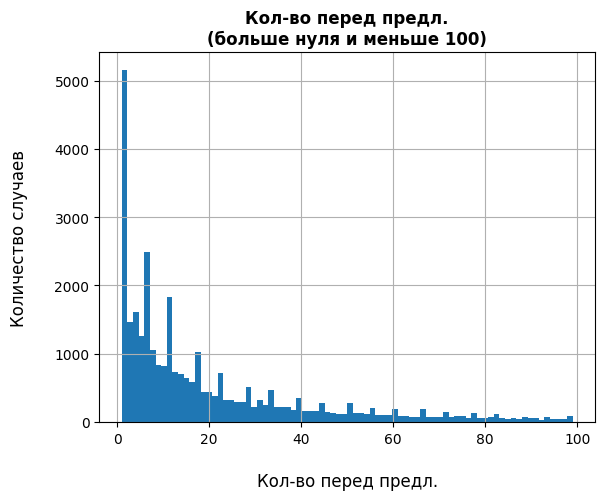

In [134]:
pricing_final[(pricing_final['Кол-во перед предл.']<100)&(pricing_final['Кол-во перед предл.']>0)]['Кол-во перед предл.'].hist(bins=80)
plt.title("Кол-во перед предл.\n(больше нуля и меньше 100)", fontsize=12, fontweight="bold")
plt.xlabel("\nКол-во перед предл.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Количество перед предложением

In [135]:
pricing_final['Кол-во перед предл.'] = pricing_final.groupby('key')['qty'].cumsum() - pricing_final['qty']

#### Маржа по предложению

In [136]:
pricing_final['Маржа по предл.'] = pricing_final['usd'] / pricing_final['С-ть'] - 1

In [137]:
pricing_final['Маржа по предл.'] = pricing_final['usd'] / pricing_final['С-ть'] - 1

count    44483.000000
mean         6.046282
std         60.720230
min         -0.935207
25%          0.155154
50%          0.369239
75%          0.732221
max       2875.821559
Name: Маржа по предл., dtype: float64


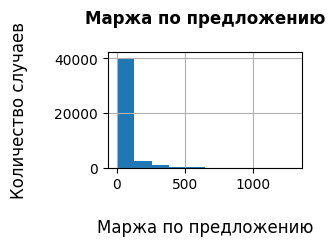

In [138]:
print(pricing_final['Маржа по предл.'].describe())
pricing_final['Кол-во перед предл.'].hist(bins=10, figsize=(2.5, 1.5))
plt.title("Маржа по предложению\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМаржа по предложению", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Разница с ценой

In [139]:
our_prices = pricing_final[pricing_final['logo']==our_logo]

In [140]:
our_prices = our_prices.rename(columns={'usd': 'usd_our'})

In [141]:
pricing_final = pricing_final.merge(our_prices[['usd_our','key']], on='key', how='left')

In [142]:
pricing_final['Разница с ценой'] = (1 - pricing_final['usd'] / pricing_final['usd_our']).round(3)  

#### Выбор места (целевой признак)

In [143]:
pricing_final['Выбор места'] = (pricing_final['№ предложения'] == pricing_final['place_final'])*1

In [144]:
pricing_final['Выбор места'].value_counts() 

0    36987
1     7496
Name: Выбор места, dtype: int64

In [145]:
pricing_final.columns

Index(['Производитель', 'Номер', 'Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 'рек. цена', 'Место',
       '№ предложения', 'Наим.', 'кузов', 'Чей товар новый', 'file', 'key',
       'place', 'key_final', 'logo', 'qty', 'days', 'rub', 'usd',
       'place_final', 'logo_qty', 'Кол-во перед предл.', 'Маржа по предл.',
       'usd_our', 'Разница с ценой', 'Выбор места'],
      dtype='object')

### Создание main, датасета для моделей

In [146]:
main = pricing_final[['Производитель', 'Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть',
       'кузов', 'Чей товар новый', 
       'logo', 'qty', 'days', 'rub', 'usd',
       'place_final', 'logo_qty', 'Кол-во перед предл.', 'Маржа по предл.',
       'usd_our', 'Разница с ценой','Выбор места']].copy()

In [147]:
main['main_key'] = pricing_final['key_final'] + ' ' + pricing_final['logo']

In [148]:
main.set_index(['main_key'], inplace = True)

In [149]:
#main

In [150]:
interval_cols = ['Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 
       'qty', 'days', 'rub', 'usd',
       'place_final', 'logo_qty', 'Кол-во перед предл.', 'Маржа по предл.',
       'usd_our', 'Разница с ценой']

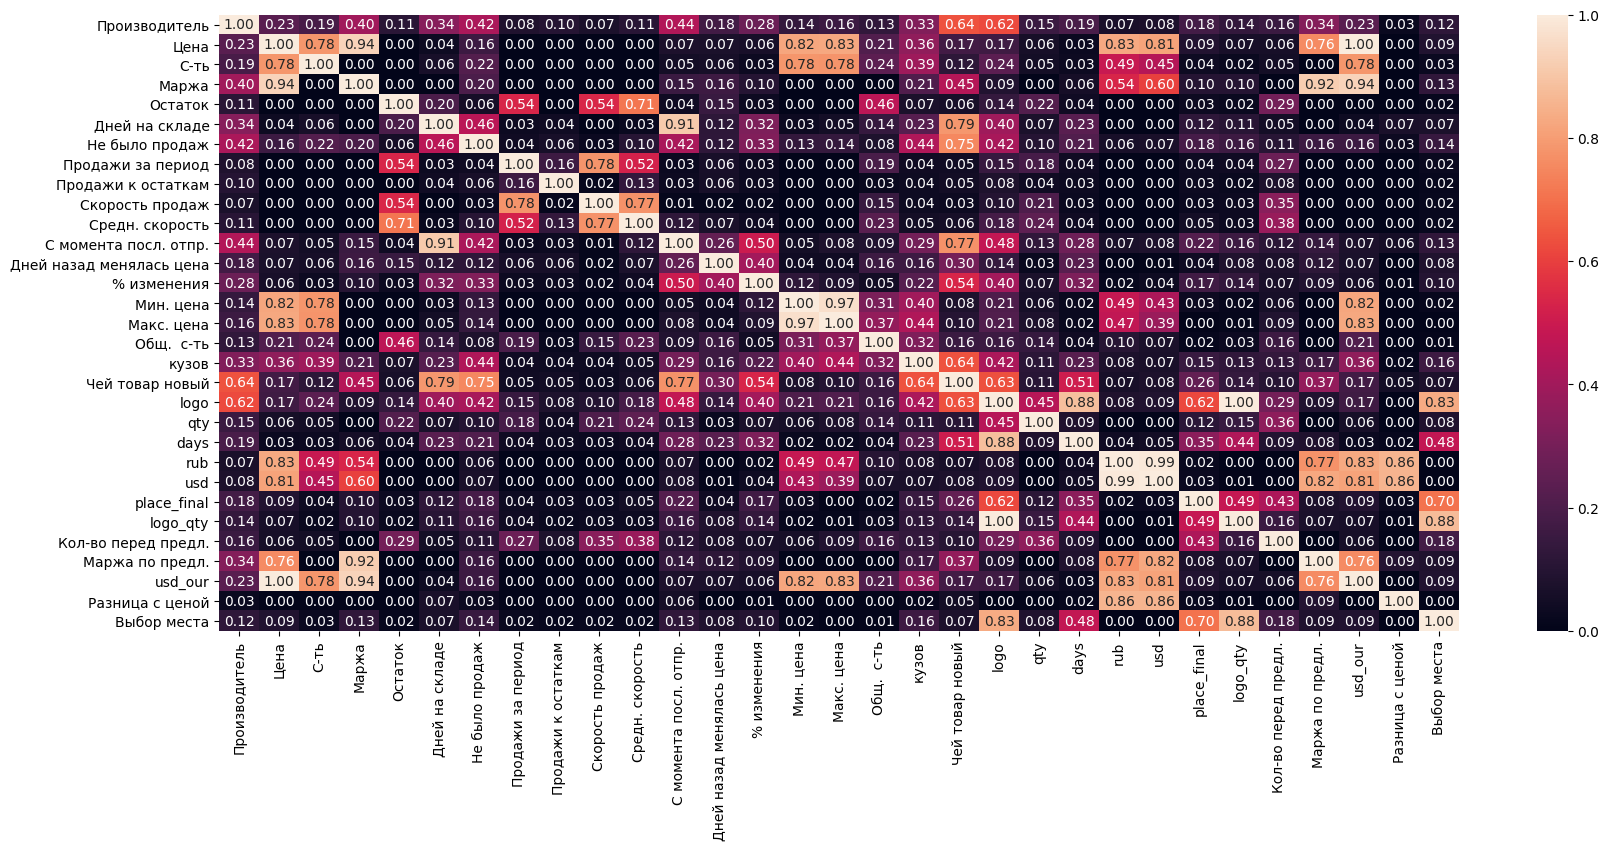

In [151]:
ig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(main.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f') 
display()

In [152]:
main.drop('Маржа', axis=1, inplace=True)

In [153]:
main.drop('С момента посл. отпр.', axis=1, inplace=True)

In [154]:
main.drop('usd_our', axis=1, inplace=True)

In [155]:
main.drop('Мин. цена', axis=1, inplace=True)

In [156]:
main.drop('logo_qty', axis=1, inplace=True)

In [157]:
main.drop('rub', axis=1, inplace=True)

После удаления столбцов для удаления мультиколлинеарности.

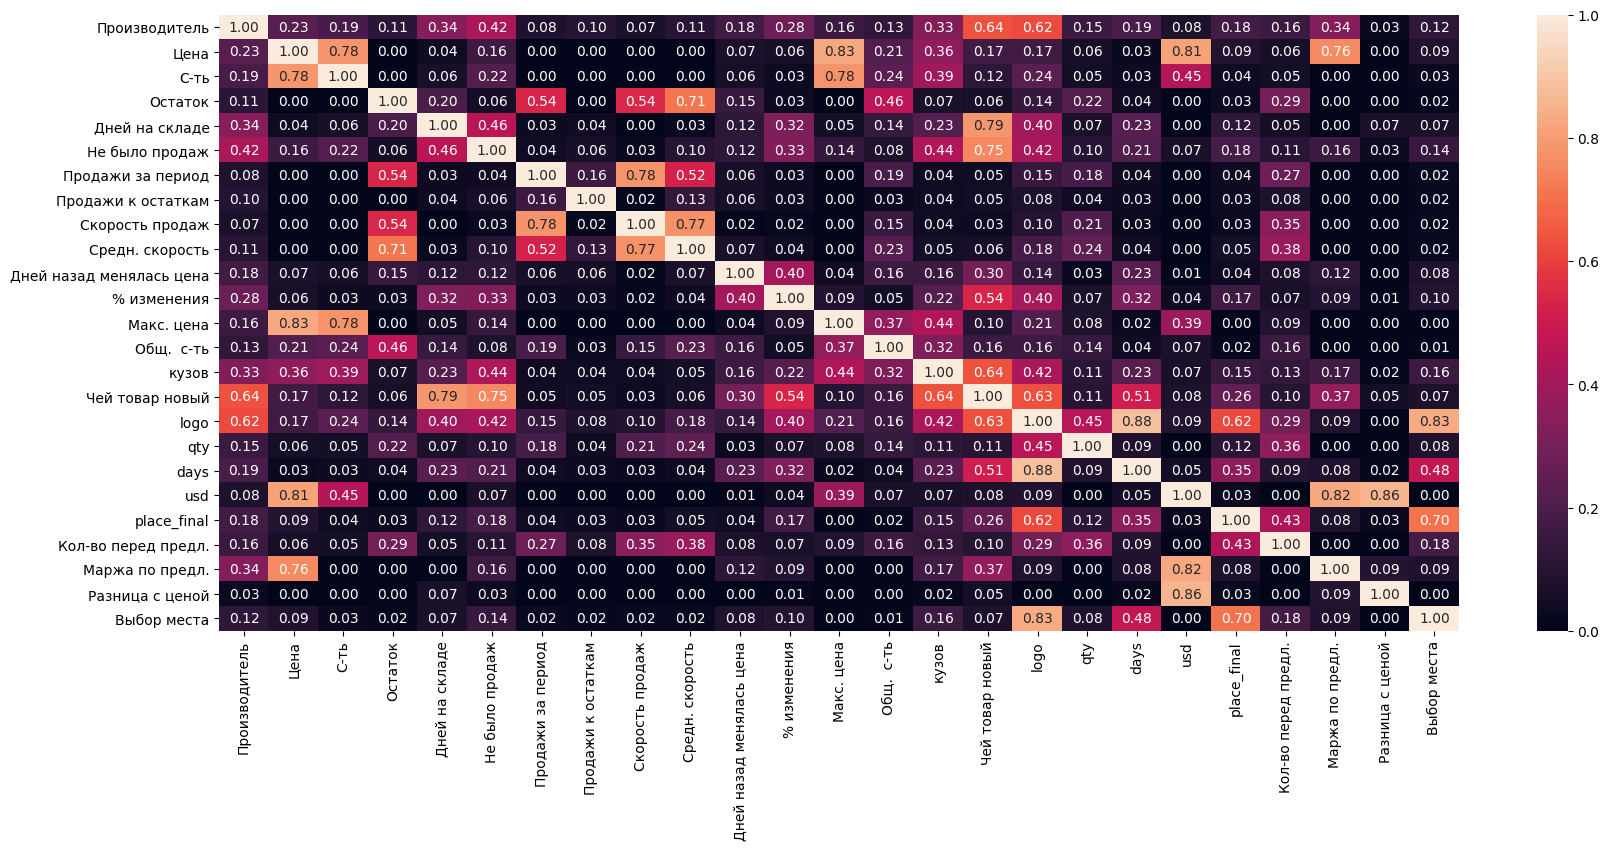

In [158]:
ig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(main.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f') 
display()

Для разбивки на тестовую и тренировочную выборки создадим датасет из уникальных ключей.

In [159]:
df_for_split = pd.DataFrame(pricing_final['key'].unique())

In [160]:
df_for_split.columns = ['key']

In [161]:
df_for_split_train, df_for_split_test = train_test_split(df_for_split, random_state=RANDOM_STATE)

In [162]:
len(df_for_split_train)

5622

In [163]:
len(df_for_split_test)

1874

Для соединения датасетов придется добавить поле "key" из датасета pricing_final в датасет main, потом удалить это поле, посколько оно больше ни для чего не нужно.

In [164]:
len(main)

44483

In [165]:
len(pricing_final)

44483

In [166]:
main = main.assign(key=pricing_final['key'].values)

In [167]:
X_y_train = main.merge(df_for_split_train, on='key', how='inner')

In [168]:
len(X_y_train)

33445

In [169]:
X_y_test = main.merge(df_for_split_test, on='key', how='inner')

In [170]:
len(X_y_test)

11038

In [171]:
X_y_train.drop(columns=['key'], inplace=True)

In [172]:
X_y_test.drop(columns=['key'], inplace=True)

In [173]:
y_train = X_y_train['Выбор места']

In [174]:
X_train = X_y_train.drop(columns='Выбор места')

In [175]:
y_test = X_y_test['Выбор места']

In [176]:
X_test = X_y_test.drop(columns='Выбор места')

In [177]:
cat_col_names = ['Производитель', 'кузов', 'Чей товар новый','logo']

In [178]:
ord_col_names = ['days', 'place_final']

In [179]:
num_col_names = ['Цена', 'С-ть', 'Остаток', 'Дней на складе',
       'Не было продаж', 'Продажи за период', 'Продажи к остаткам',
       'Скорость продаж', 'Средн. скорость', 'Дней назад менялась цена',
       '% изменения', 'Макс. цена', 'Общ.  с-ть', 
       'qty', 'usd', 'Кол-во перед предл.',
       'Маржа по предл.', 'Разница с ценой']

In [180]:
X_train_light = X_train.copy() 
X_test_light = X_test.copy() 

In [181]:
X_train_light[cat_col_names+ord_col_names] = X_train_light[cat_col_names+ord_col_names].astype('category')

In [182]:
X_test_light[cat_col_names+ord_col_names] = X_test_light[cat_col_names+ord_col_names].astype('category')

In [183]:
parameters_light =  {
    'num_leaves': distributions.IntDistribution(31, 100),
    'learning_rate': distributions.FloatDistribution(0.01, 0.5) #(0.1, 0.5) 
} 

In [184]:
model_light = LGBMClassifier(random_state=RANDOM_STATE)

In [185]:
oscv_light = OptunaSearchCV(
    model_light,
    parameters_light,
    random_state=RANDOM_STATE,
    n_trials = 10,
    cv = 5,
    scoring = 'accuracy'
)

C:\Users\a-2\AppData\Local\Temp\ipykernel_13480\4056963137.py:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_light = OptunaSearchCV(


In [186]:
oscv_light.fit(X_train_light, y_train)

[I 2025-08-19 12:30:18,841] A new study created in memory with name: no-name-c15fdaab-77f7-4a3f-baa2-3088595c0101


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 26756, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168074 -> initscore=-1.599336
[LightGBM] [Info] Start training from score -1.599336
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3615
[LightGBM] [Info] Number of data points in the train set: 26756, number of used f

[I 2025-08-19 12:30:22,974] Trial 0 finished with value: 0.9390940349828076 and parameters: {'num_leaves': 62, 'learning_rate': 0.41798969583433027}. Best is trial 0 with value: 0.9390940349828076.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 26756, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168074 -> initscore=-1.599336
[LightGBM] [Info] Start training from score -1.599336
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3615
[LightGBM] [Info] Number of data points in the train set: 26756, number of used f

[I 2025-08-19 12:30:25,700] Trial 1 finished with value: 0.9571535356555539 and parameters: {'num_leaves': 35, 'learning_rate': 0.166529153009486}. Best is trial 1 with value: 0.9571535356555539.


...

[I 2025-08-19 12:30:55,770] Trial 8 finished with value: 0.9073703094632979 and parameters: {'num_leaves': 90, 'learning_rate': 0.48713392792056365}. Best is trial 2 with value: 0.9598744206906862.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014954 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 26756, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168074 -> initscore=-1.599336
[LightGBM] [Info] Start training from score -1.599336
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4497, number of negative: 22259
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3615
[LightGBM] [Info]

[I 2025-08-19 12:30:59,597] Trial 9 finished with value: 0.9382867394229333 and parameters: {'num_leaves': 63, 'learning_rate': 0.4766662391254943}. Best is trial 2 with value: 0.9598744206906862.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5622, number of negative: 27823
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3709
[LightGBM] [Info] Number of data points in the train set: 33445, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168097 -> initscore=-1.599176
[LightGBM] [Info] Start training from score -1.599176


OptunaSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_jobs=1,
               param_distributions={'learning_rate': FloatDistribution(high=0.5, log=False, low=0.01, step=None),
                                    'num_leaves': IntDistribution(high=100, log=False, low=31, step=1)},
               random_state=42, scoring='accuracy')

In [187]:
oscv_light.best_params_

{'num_leaves': 64, 'learning_rate': 0.15614819936891405}

In [188]:
oscv_light.best_score_

0.9598744206906862

In [189]:
predictions_light = oscv_light.predict_proba(X_test_light)

In [190]:
predictions_light = oscv_light.predict(X_test_light)

In [191]:
predictions_light

array([1, 0, 1, ..., 0, 1, 0])

In [192]:
result_light_final = accuracy_score(y_test, predictions_light)

In [193]:
result_light_final

0.9624932052908135

На кросс-валидации и тестовой выборке получены достаточно хорошие показатели.